In [1]:
import torch
from torch.utils.data import DataLoader
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm import tqdm

import timesfm.pytorch_patched_decoder_appfl as TFMappfl
import timesfm.custom_data_set_appfl as TFMdset

plt.rcParams['text.usetex'] = True
plt.rcParams.update({'font.size': 14})
plt.rcParams['text.latex.preamble'] = r'\usepackage{times}'

device = torch.device('cpu')

TimesFM v1.2.0. See https://github.com/google-research/timesfm/blob/master/README.md for updated APIs.
Loaded Jax TimesFM.
Loaded PyTorch TimesFM.


In [2]:
# lookback and lookahead
lookback, lookahead = 512, 96

In [3]:
# batch size
batch_size = 1024

# data
model = TFMappfl.TimesFmAppfl(lookback = lookback, lookahead = lookahead).to(device)
model.load_state_dict(torch.load('/home/shourya01/timesfm/timesfm-1.0-200m-pytorch/torch_model.ckpt',map_location=device))

<All keys matched successfully>

In [4]:
# get dataset
data = np.load('/eagle/ParaLLMs/ComStock/trial_1000bldg_per_iso/CAISO.npy') # any comstock-style numpy matrix
dataset_train, dataset_test = TFMdset.get_data_and_generate_train_test_sets(
    data_array = data,
    split_ratios = [0.8,0.1,0.1],
    dataset_kwargs = {
        'num_bldg' : data.shape[0],
        'lookback' : lookback,
        'lookahead' : lookahead,
        'normalize' : True,
        'dtype' : torch.float32,
        'context_len' : 512
    }
)

In [5]:
# get dataloader
dl = DataLoader(dataset_train, batch_size = batch_size, shuffle=False)
dl_test = DataLoader(dataset_test, batch_size = batch_size, shuffle=False)

In [6]:
# forecast using forward() for first item in batch
for itm in dl_test:
    ts, y = itm
    ts = ts.to(device)
    forecast_forward = model(ts)
    break


In [9]:
# extach data
seq_lookback = ts[0,:].detach().numpy()
seq_lookahead_forward = forecast_forward.detach().cpu().numpy()[0,:]
seq_lookahead_gt = y[0,:].numpy()

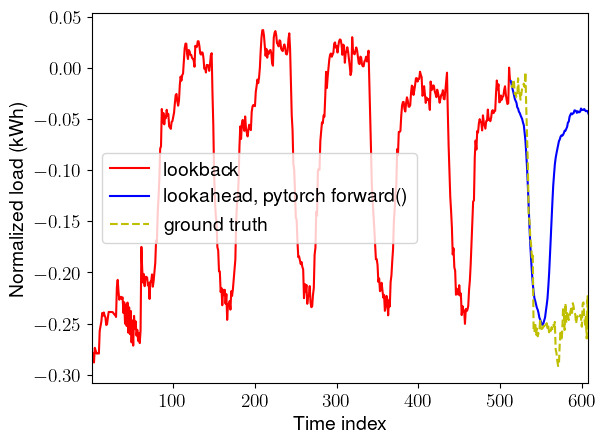

In [10]:
# plot
plt.plot(np.arange(1,lookback+1),seq_lookback,'r',label='lookback')
plt.plot(np.arange(lookback+1,lookback+lookahead+1),seq_lookahead_forward,'b',label='lookahead, pytorch forward()')
plt.plot(np.arange(lookback+1,lookback+lookahead+1),seq_lookahead_gt,'y--',label='ground truth')
plt.xlim(1,lookback+lookahead)
plt.xlabel('Time index')
plt.ylabel('Normalized load (kWh)')
plt.legend()
plt.show()